In [1]:
print("Student Performance Prediction Project")
print("Setup successful!")

Student Performance Prediction Project
Setup successful!


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_students = 100

data = {
    "attendance": np.random.randint(40, 101, n_students),
    "previous_marks": np.random.randint(35, 96, n_students),
    "study_hours": np.round(np.random.uniform(1, 6, n_students), 1),
    "assignments_completed": np.random.randint(2, 11, n_students)
}

df = pd.DataFrame(data)

# Generate final marks based on the student features
df["final_marks"] = (
    0.30 * df["attendance"]
    + 0.40 * df["previous_marks"]
    + 3.0 * df["study_hours"]
    + 1.5 * df["assignments_completed"]
    + np.random.normal(0, 5, n_students)
)

# Keep marks within 0–100
df["final_marks"] = df["final_marks"].clip(0, 100).round(1)

print("Dataset created successfully!")
print(df.head())
print("\nDataset shape:", df.shape)

Dataset created successfully!
   attendance  previous_marks  study_hours  assignments_completed  final_marks
0          78              82          2.0                     10         83.3
1          91              49          5.7                      3         67.7
2          68              42          4.0                      3         51.8
3          54              48          4.5                      3         46.9
4          82              57          5.4                      7         70.3

Dataset shape: (100, 5)


In [4]:
import os

# Create the data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Save the dataset
df.to_csv("data/student_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [5]:
import os

print(os.path.exists("data/student_data.csv"))

True


In [6]:
# Step 4: Inspect the dataset

print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe())

First 5 rows:


,attendance,previous_marks,study_hours,assignments_completed,final_marks
0,78,82,2.0,10,83.3
1,91,49,5.7,3,67.7
2,68,42,4.0,3,51.8
3,54,48,4.5,3,46.9
4,82,57,5.4,7,70.3



Dataset shape:
(100, 5)

Column names:
['attendance', 'previous_marks', 'study_hours', 'assignments_completed', 'final_marks']

Data types:
attendance                 int32
previous_marks             int32
study_hours              float64
assignments_completed      int32
final_marks              float64
dtype: object

Missing values:
attendance               0
previous_marks           0
study_hours              0
assignments_completed    0
final_marks              0
dtype: int64

Duplicate rows:
0

Statistical summary:


,attendance,previous_marks,study_hours,assignments_completed,final_marks
count,100.000000,100.000000,100.00000,100.000000,100.000000
mean,70.700000,64.290000,3.60100,5.640000,66.499000
std,18.472748,17.302008,1.40838,2.603494,12.132988
min,41.000000,35.000000,1.00000,2.000000,40.000000
25%,54.750000,49.000000,2.30000,3.000000,56.600000
50%,69.500000,65.000000,3.60000,6.000000,67.000000
75%,86.500000,78.000000,4.75000,8.000000,74.400000
max,100.000000,95.000000,6.00000,10.000000,97.900000


In [7]:
# Step 5: Data Cleaning and Preprocessing

# 1. Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# 2. Handle missing numerical values
numeric_columns = [
    "attendance",
    "previous_marks",
    "study_hours",
    "assignments_completed",
    "final_marks"
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# 3. Remove duplicate rows
df = df.drop_duplicates()

# 4. Remove invalid attendance values
df = df[(df["attendance"] >= 0) & (df["attendance"] <= 100)]

# 5. Remove invalid marks
df = df[(df["previous_marks"] >= 0) & (df["previous_marks"] <= 100)]
df = df[(df["final_marks"] >= 0) & (df["final_marks"] <= 100)]

# 6. Remove invalid study hours
df = df[df["study_hours"] >= 0]

# 7. Remove invalid assignment values
df = df[df["assignments_completed"] >= 0]

print("\nCleaning completed!")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())

print("\nDataset shape after cleaning:")
print(df.shape)


Missing values before cleaning:
attendance               0
previous_marks           0
study_hours              0
assignments_completed    0
final_marks              0
dtype: int64

Cleaning completed!

Missing values after cleaning:
attendance               0
previous_marks           0
study_hours              0
assignments_completed    0
final_marks              0
dtype: int64

Duplicate rows after cleaning:
0

Dataset shape after cleaning:
(100, 5)


In [8]:
df.to_csv("data/cleaned_student_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualization libraries loaded!")

Visualization libraries loaded!


C:\Users\BHANU PRAKASH\anaconda3\anaconda.3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


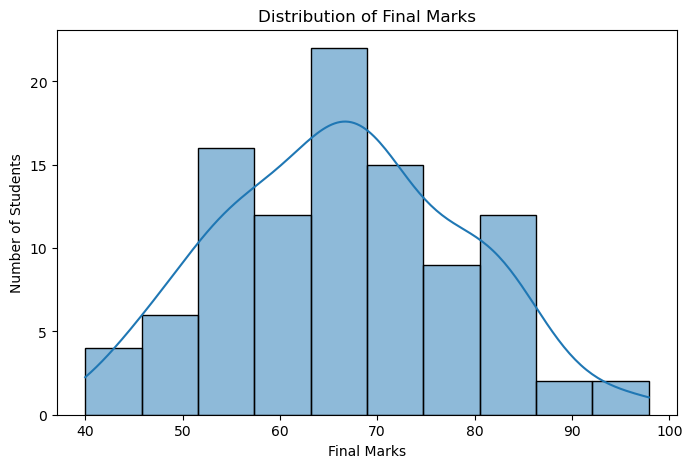

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["final_marks"], bins=10, kde=True)

plt.title("Distribution of Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")

plt.show()

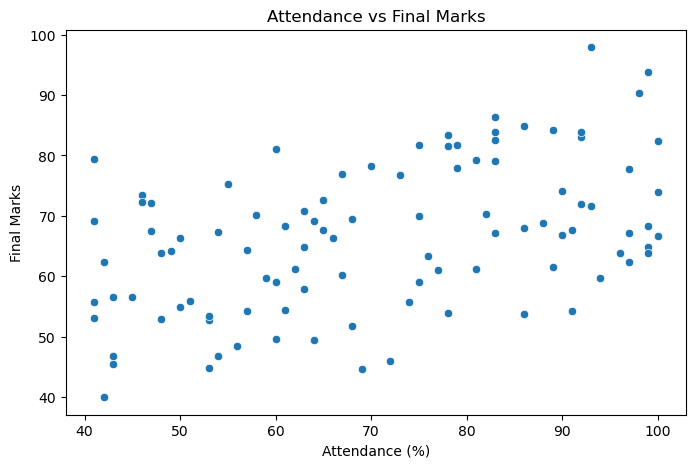

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="attendance",
    y="final_marks"
)

plt.title("Attendance vs Final Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")

plt.show()

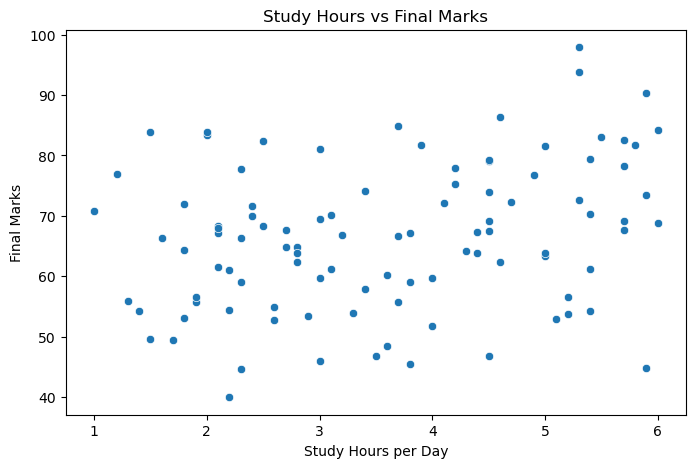

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="study_hours",
    y="final_marks"
)

plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours per Day")
plt.ylabel("Final Marks")

plt.show()

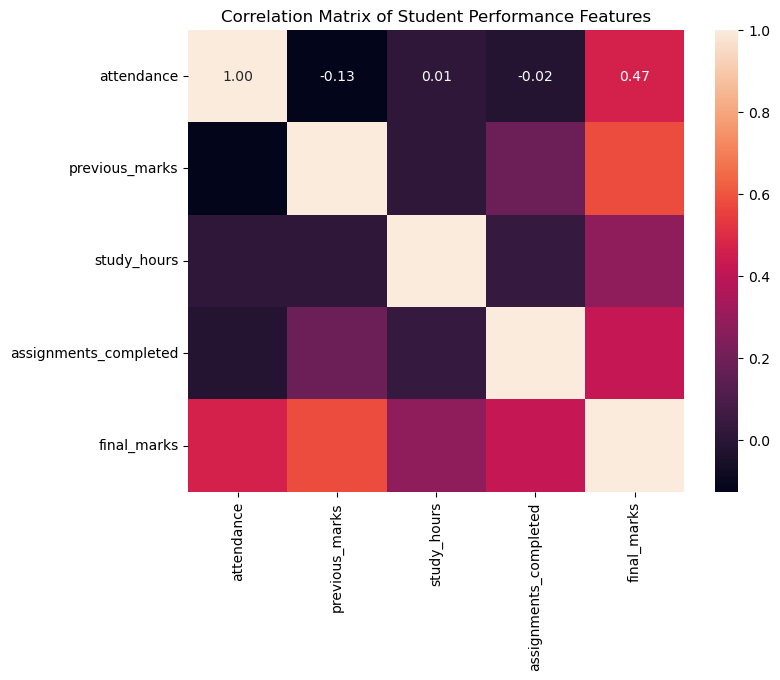

In [13]:
plt.figure(figsize=(8, 6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Student Performance Features")

plt.show()

In [14]:
# Step 7: Feature Selection

features = [
    "attendance",
    "previous_marks",
    "study_hours",
    "assignments_completed"
]

X = df[features]
y = df["final_marks"]

print("Input features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features (X):


,attendance,previous_marks,study_hours,assignments_completed
0,78,82,2.0,10
1,91,49,5.7,3
2,68,42,4.0,3
3,54,48,4.5,3
4,82,57,5.4,7



Target (y):


0    83.3
1    67.7
2    51.8
3    46.9
4    70.3
Name: final_marks, dtype: float64


X shape: (100, 4)
y shape: (100,)


In [15]:
# Step 8: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


In [16]:
# Step 9: Train Linear Regression Model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [17]:
# Step 10: Make Predictions

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[80.54439444 68.94400566 58.65779433 82.46232679 59.49876231 84.53141622
 58.0403253  61.01517858 60.20336708 78.84187431 62.81424171 48.4142282
 65.78061152 54.72524745 91.14940071 73.52763249 70.50172332 65.76487331
 62.05179863 53.46030533]


In [18]:
# Step 11: Model Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

Model Evaluation Results
------------------------
MAE  : 4.77
MSE  : 32.71
RMSE : 5.72
R²   : 0.83


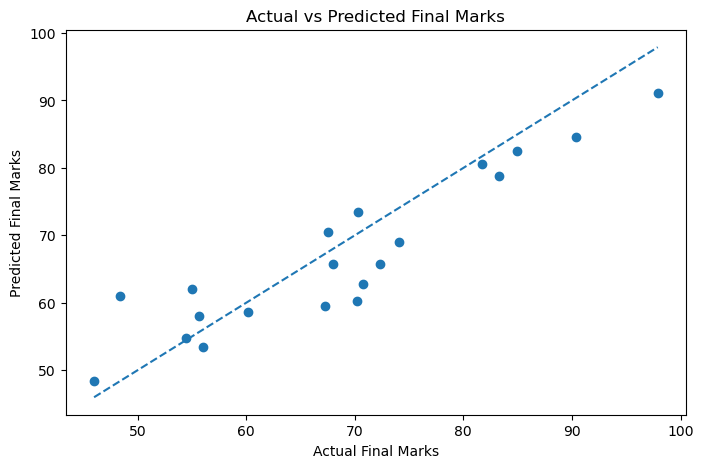

In [19]:
# Step 12: Actual vs Predicted Marks

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

# Perfect prediction reference line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")

plt.show()

In [20]:
# Step 13: Prediction Results

results = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": np.round(y_pred, 1)
})

results["Error"] = np.round(
    results["Actual Marks"] - results["Predicted Marks"],
    1
)

display(results)

,Actual Marks,Predicted Marks,Error
0,81.7,80.5,1.2
1,74.1,68.9,5.2
2,60.2,58.7,1.5
3,84.9,82.5,2.4
4,67.3,59.5,7.8
5,90.4,84.5,5.9
6,55.7,58.0,-2.3
7,48.4,61.0,-12.6
8,70.2,60.2,10.0
9,83.3,78.8,4.5


In [21]:
# Step 14: Save the trained model

import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/student_performance_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [22]:
# Step 15: Predict Performance for a New Student

new_student = pd.DataFrame({
    "attendance": [85],
    "previous_marks": [78],
    "study_hours": [3.5],
    "assignments_completed": [8]
})

predicted_marks = model.predict(new_student)[0]

print("Student Information")
print("-------------------")
print("Attendance:", new_student["attendance"].iloc[0], "%")
print("Previous Marks:", new_student["previous_marks"].iloc[0])
print("Study Hours:", new_student["study_hours"].iloc[0])
print("Assignments Completed:", new_student["assignments_completed"].iloc[0])

print("\nPredicted Final Marks:", round(predicted_marks, 2))

Student Information
-------------------
Attendance: 85 %
Previous Marks: 78
Study Hours: 3.5
Assignments Completed: 8

Predicted Final Marks: 79.77


In [23]:
# Step 16: Performance Category

def performance_category(marks):
    if marks >= 80:
        return "High"
    elif marks >= 60:
        return "Medium"
    else:
        return "Low"

category = performance_category(predicted_marks)

print("Predicted Final Marks:", round(predicted_marks, 2))
print("Performance Category:", category)

Predicted Final Marks: 79.77
Performance Category: Medium


In [24]:
# Step 17: Student Performance Prediction Function

def predict_student(attendance, previous_marks, study_hours, assignments_completed):

    student = pd.DataFrame({
        "attendance": [attendance],
        "previous_marks": [previous_marks],
        "study_hours": [study_hours],
        "assignments_completed": [assignments_completed]
    })

    predicted_marks = model.predict(student)[0]

    category = performance_category(predicted_marks)

    print("Student Performance Prediction")
    print("--------------------------------")
    print("Attendance:", attendance, "%")
    print("Previous Marks:", previous_marks)
    print("Study Hours:", study_hours)
    print("Assignments Completed:", assignments_completed)
    print("\nPredicted Final Marks:", round(predicted_marks, 2))
    print("Performance Category:", category)

In [25]:
predict_student(90, 85, 4, 9)

Student Performance Prediction
--------------------------------
Attendance: 90 %
Previous Marks: 85
Study Hours: 4
Assignments Completed: 9

Predicted Final Marks: 86.83
Performance Category: High


In [26]:
predict_student(60, 55, 2, 5)

Student Performance Prediction
--------------------------------
Attendance: 60 %
Previous Marks: 55
Study Hours: 2
Assignments Completed: 5

Predicted Final Marks: 54.47
Performance Category: Low


In [27]:
predict_student(45, 40, 1, 3)

Student Performance Prediction
--------------------------------
Attendance: 45 %
Previous Marks: 40
Study Hours: 1
Assignments Completed: 3

Predicted Final Marks: 38.3
Performance Category: Low
